In [1]:
import pymc as pm; import arviz as az; import sys; import numpy as np; import pickle; import pytensor
import nutpie; import pytensor.tensor as pt; import matplotlib.pyplot as plt
sys.path.append(r'C:\Users\awast\OneDrive\Desktop\MKM')
from _CO_Oxidation.config import kb_eV, T, kb_J, h, F, N_A
from _CO_Oxidation import wrapper_base as wp
from _CO_Oxidation.wrapper_base import plot_posteriors, plot_model_fits, plot_coverages, plot_drc, simulate_fake_data

C_KOH_list = np.array([0.25, 0.5, 1]) # in M 
P_CO_list = 0.01*np.array([0.1, 1, 10, 100]) # in atm 
experiments_data = pickle.load(open('import_Ag10Pd90_base_replicates.pkl', 'rb'))
wp.process_experimental_data(experiments_data, C_KOH_list, P_CO_list)
E_in = wp.E_in; P_CO_in = wp.P_CO_in; C_KOH_in = wp.C_KOH_in

def fit_and_evaluate(model, draws=1000, tune=2000, chains=4, cores=4, init_mean=None, target_accept=0.9):
    compiled_model = nutpie.compile_pymc_model(model)
    trace = nutpie.sample(compiled_model, draws=draws, tune=tune, chains=chains, cores=cores, init_mean=init_mean, target_accept=target_accept)
    pm.compute_log_likelihood(trace, progressbar=False, model=model)
    loo = az.loo(trace, pointwise=True)
    print(loo); az.plot_khat(loo); plt.title("Pareto k diagnostic"); plt.show()
    trace = wp.add_post_sampling_observables(trace)
    return trace, loo

def observables(log_rate):
    pm.Deterministic('log_rate', log_rate)
    sigma_rel = pm.HalfNormal('sigma_rel', sigma=0.1) # 0.1
    sigma_exp = wp.log_rate_SD_obs 
    sigma_tot = pm.math.sqrt(sigma_rel**2 + sigma_exp**2)
    rate = pm.LogNormal('rate', mu=log_rate, sigma=sigma_tot, observed=wp.rate_obs_matrix)
    return rate

Ag_comp = 0.1

# BF (!)
Good model. 

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.14,63
,3000,0,0.14,15
,3000,0,0.13,63
,3000,0,0.13,127


Computed from 4000 posterior samples and 1431 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  2966.00    66.72
p_loo        5.58        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1431  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



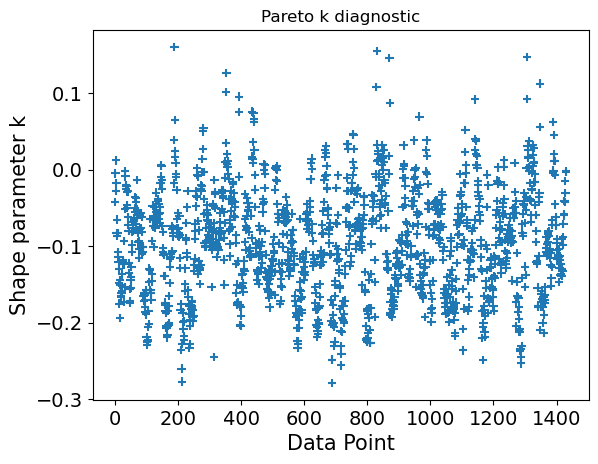

Sampling: [Gact2_0, beta_2, deltaG1_0, deltaG4_0, deltaG5_0, q, sigma_rel]


            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0 -0.125  0.001  -0.127   -0.123      0.000    0.000    3404.0    2729.0   1.00
deltaG4_0  0.143  0.007   0.131    0.158      0.000    0.000    1941.0    2145.0   1.00
deltaG5_0  0.028  0.005   0.019    0.038      0.000    0.000     526.0    1076.0   1.01
beta_2     0.119  0.042   0.038    0.194      0.002    0.001     533.0     578.0   1.01
q          0.301  0.033   0.236    0.359      0.001    0.001     577.0     641.0   1.01
Gact2_0    0.668  0.004   0.660    0.676      0.000    0.000     527.0    1062.0   1.01
sigma_rel  0.416  0.008   0.401    0.432      0.000    0.000    4653.0    2406.0   1.00

--- Prior-to-Posterior Contraction ---
deltaG1_0: 1.000
deltaG4_0: 0.999
deltaG5_0: 0.999
beta_2: 0.979
q: 0.987
Gact2_0: 1.000
sigma_rel: 0.981


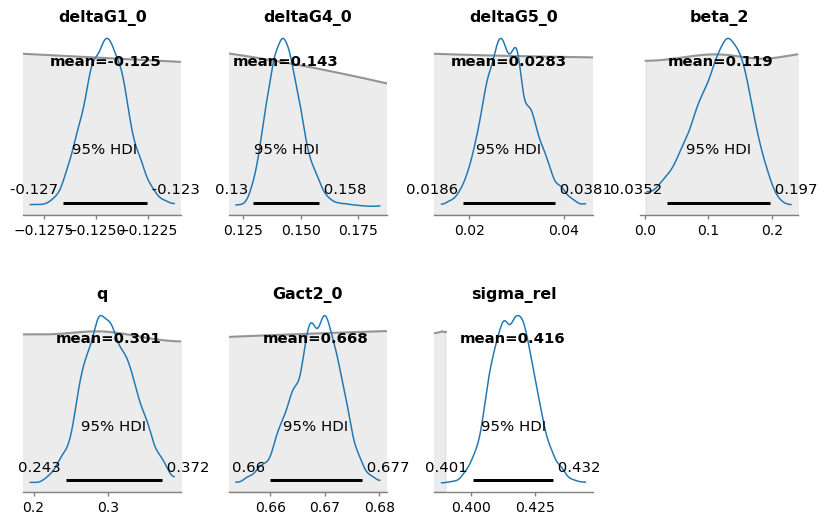

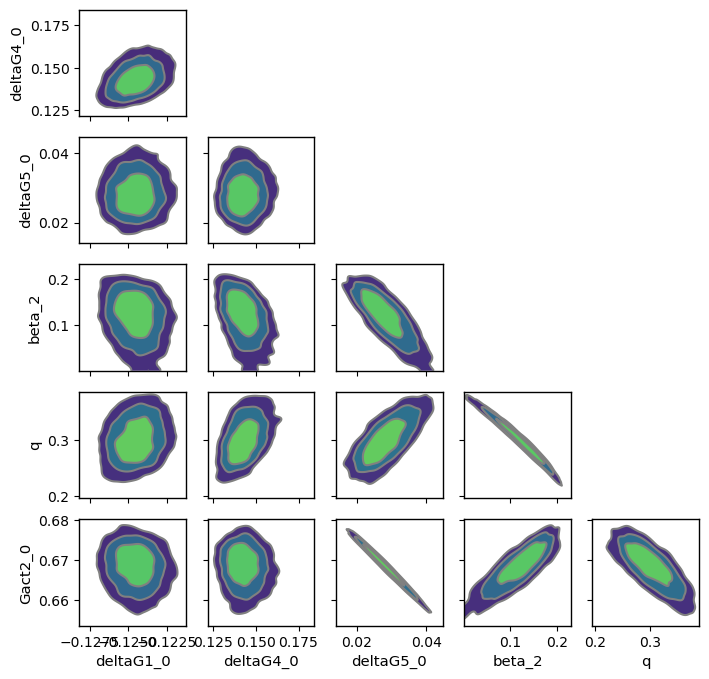

Sampling: [rate]


rate: 0.766


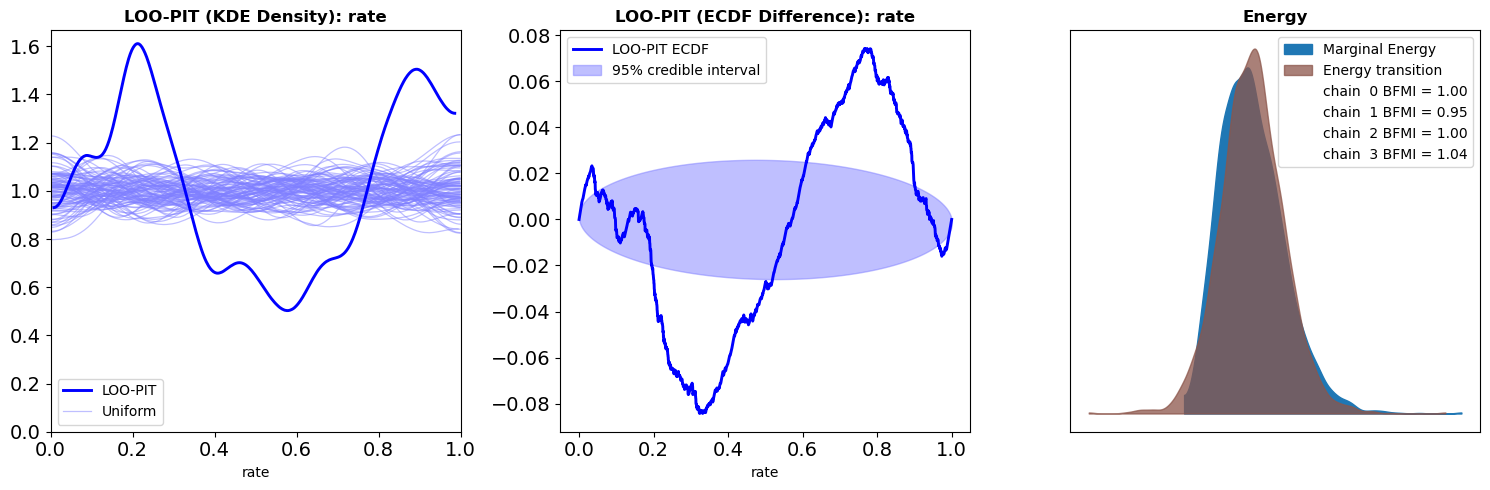

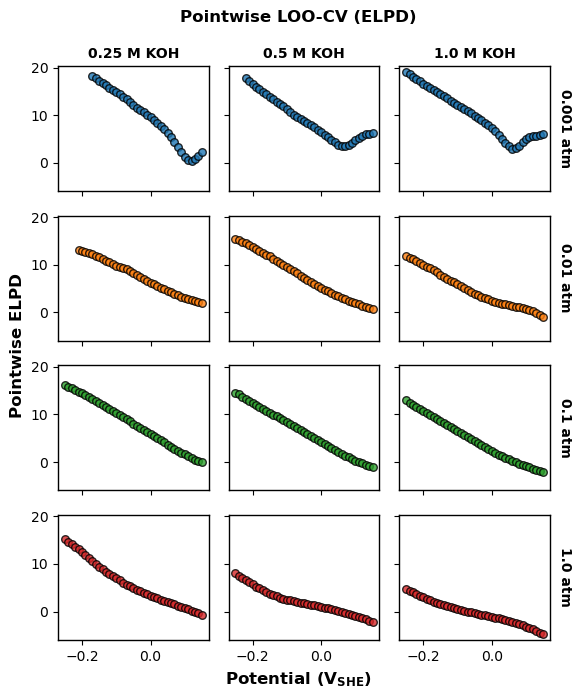

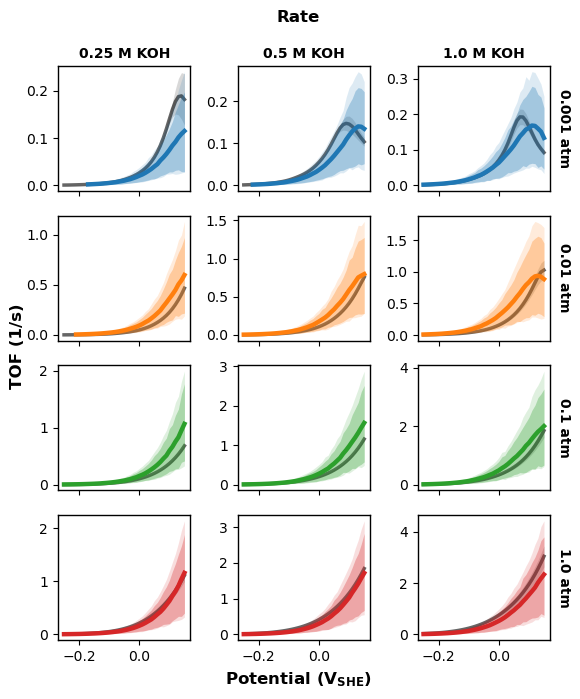

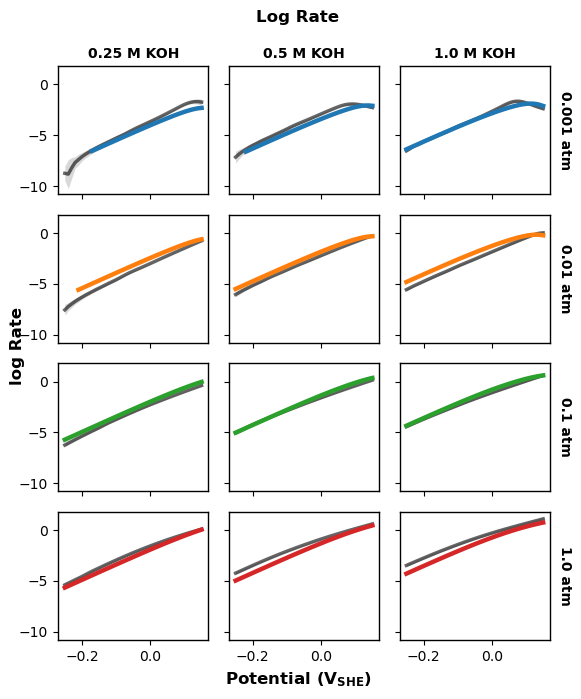

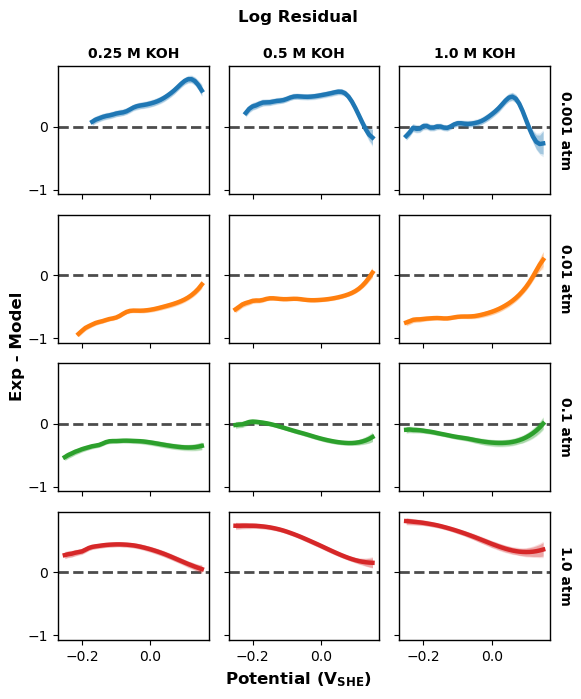

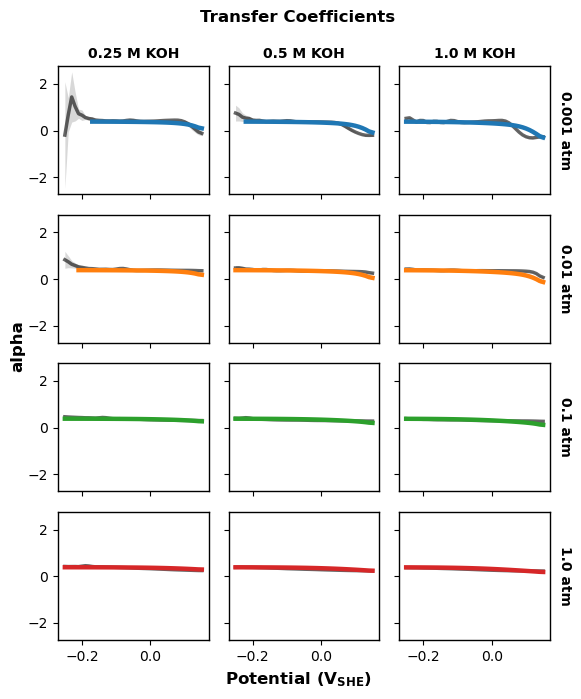

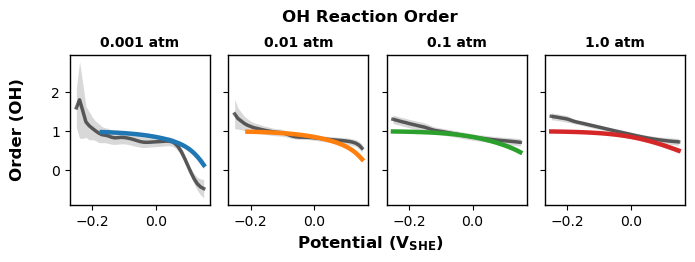

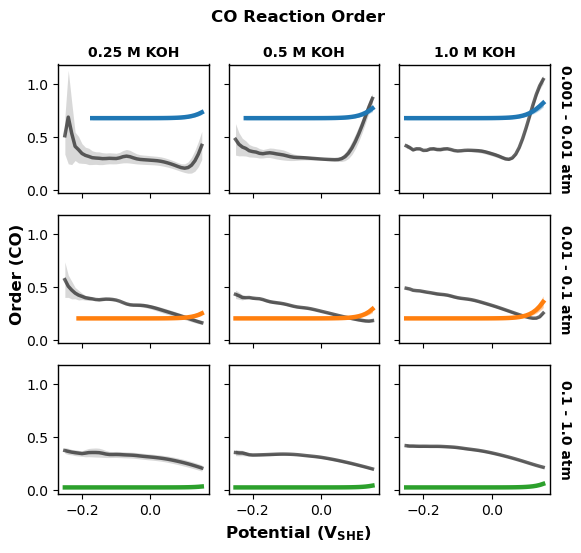

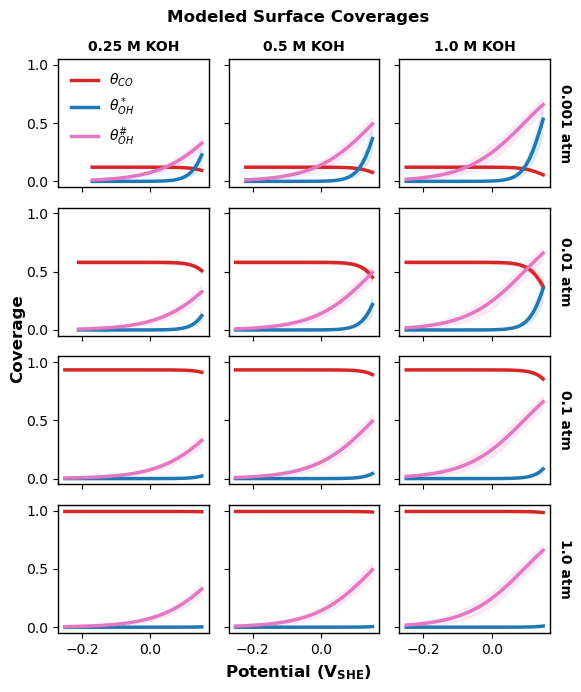

In [2]:
with pm.Model() as BF:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH(q-1)# -> COOH* + # + (1-q)(e-) (RDS) (BF)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH(q-1)# + (q)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2)
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) 
    beta_2 = pm.Uniform('beta_2', lower=0.0, upper=1.0)
    q = pm.Uniform('q', lower=0.0, upper=1.0)   
    Gact2_0 = pm.TruncatedNormal('Gact2_0', mu=0.7, sigma=0.2, lower=0.0)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - q * E_in
    Gact2 = Gact2_0 - beta_2 * (1.0 - q) * E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2 + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    log_rate = log_rate_BF
    rate = observables(log_rate) 

trace_BF, loo_BF = fit_and_evaluate(BF, target_accept=0.95)

ppc_BF = plot_posteriors(trace_BF, BF)
plot_model_fits(trace_BF, ppc_BF, loo_BF); plot_coverages(trace_BF)

# BF LH (!!)
LH has significant DRC at high potentials. Marginally higher ELPD than BF LH (deltaELPD/dse = 3.15) 

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.06,127
,3000,0,0.08,319
,3000,0,0.06,63
,3000,0,0.06,127


Computed from 4000 posterior samples and 1431 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  2978.36    66.48
p_loo        6.10        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1431  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



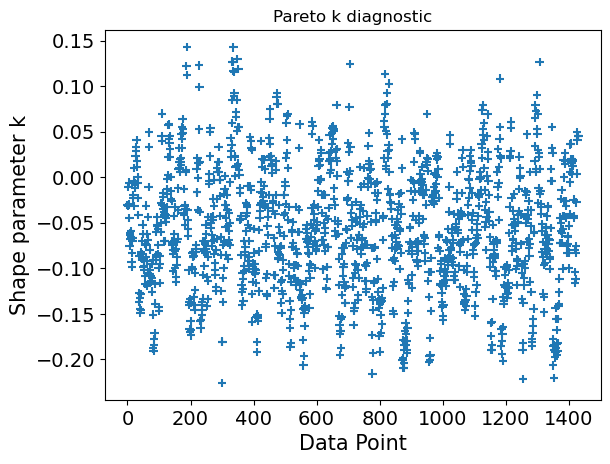

Sampling: [Gact2_BF_0, Gact2_LH_0, beta_2, deltaG1_0, deltaG4_0, deltaG5_0, q, sigma_rel]


             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.123  0.001  -0.125   -0.121      0.000    0.000    3198.0    2832.0    1.0
deltaG4_0   0.113  0.005   0.105    0.121      0.000    0.000    3067.0    2548.0    1.0
deltaG5_0   0.032  0.005   0.023    0.041      0.000    0.000     667.0    1235.0    1.0
beta_2      0.087  0.042   0.006    0.157      0.002    0.001     670.0     540.0    1.0
q           0.316  0.031   0.262    0.375      0.001    0.001     715.0     648.0    1.0
Gact2_BF_0  0.666  0.004   0.658    0.673      0.000    0.000     650.0    1175.0    1.0
Gact2_LH_0  0.723  0.004   0.715    0.731      0.000    0.000    2516.0    2023.0    1.0
sigma_rel   0.412  0.008   0.397    0.427      0.000    0.000    4990.0    2816.0    1.0

--- Prior-to-Posterior Contraction ---
deltaG1_0: 1.000
deltaG4_0: 0.999
deltaG5_0: 0.999
beta_2: 0.979
q: 0.988
Gact2_BF_0: 1.000
Gact2_LH_0: 1.000
sigma_rel: 0.982


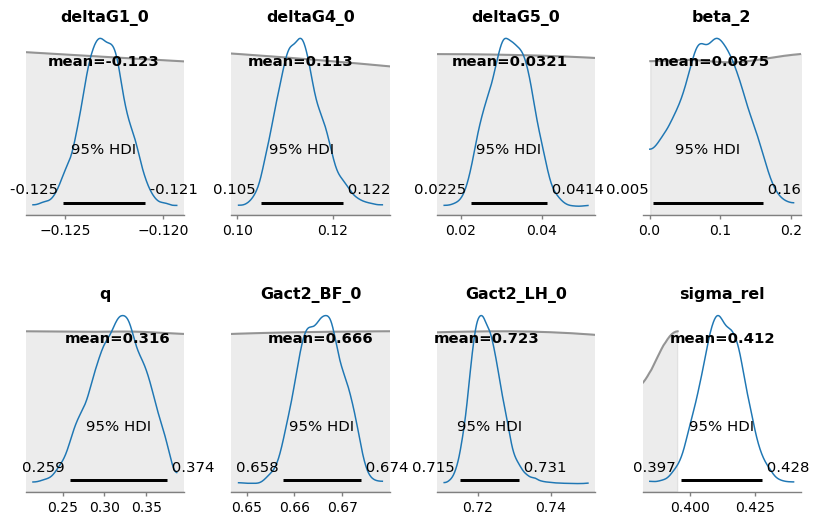

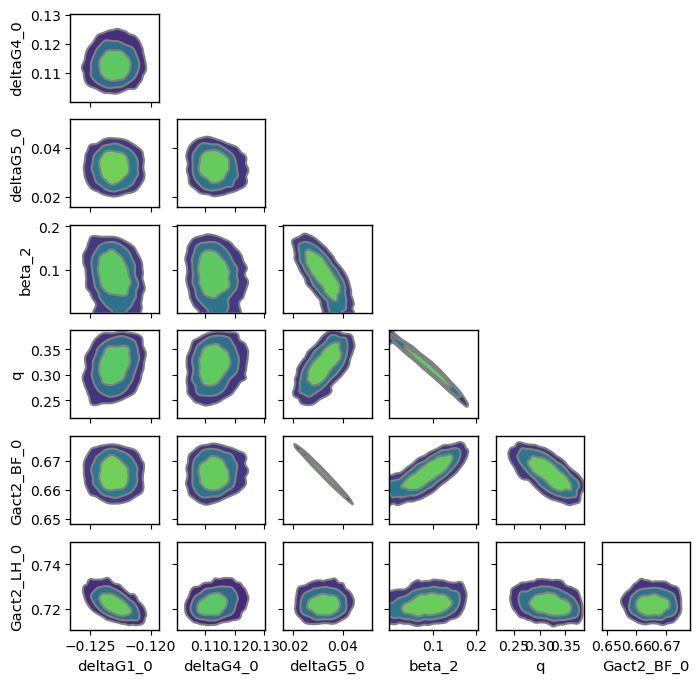

Sampling: [rate]


rate: 0.759


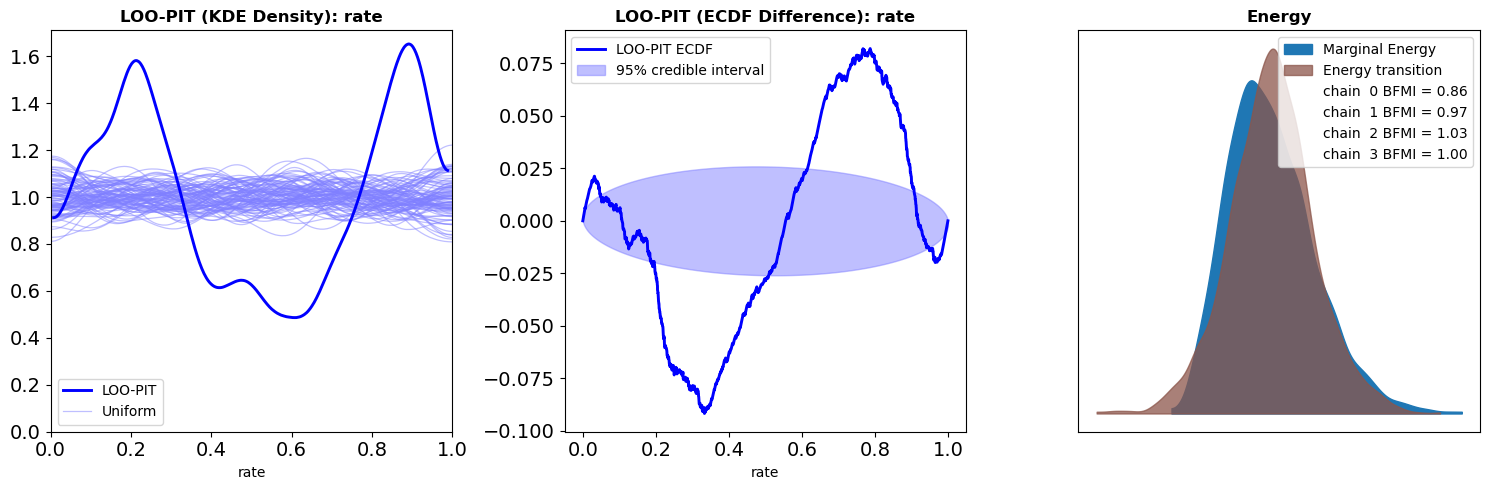

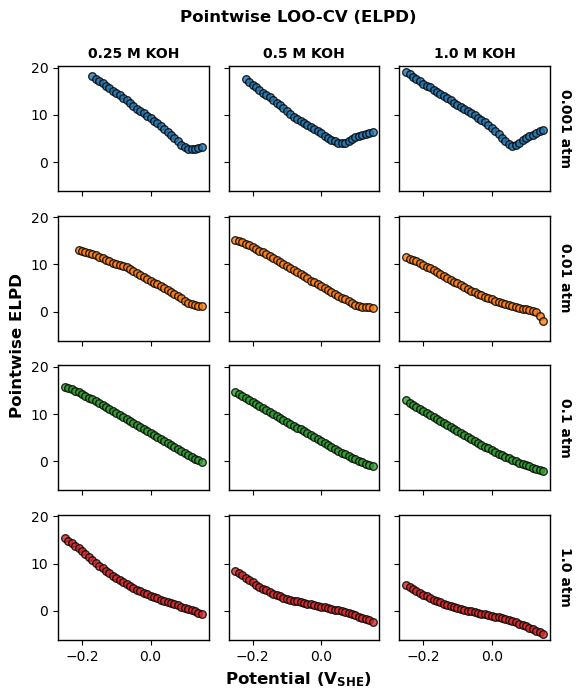

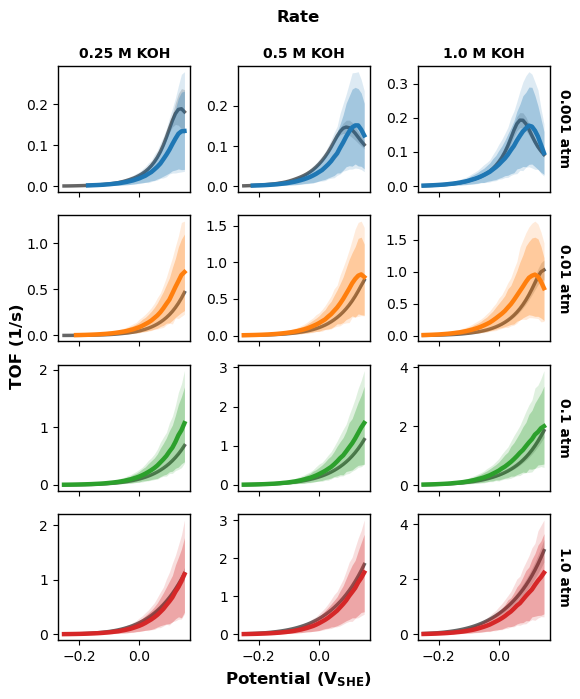

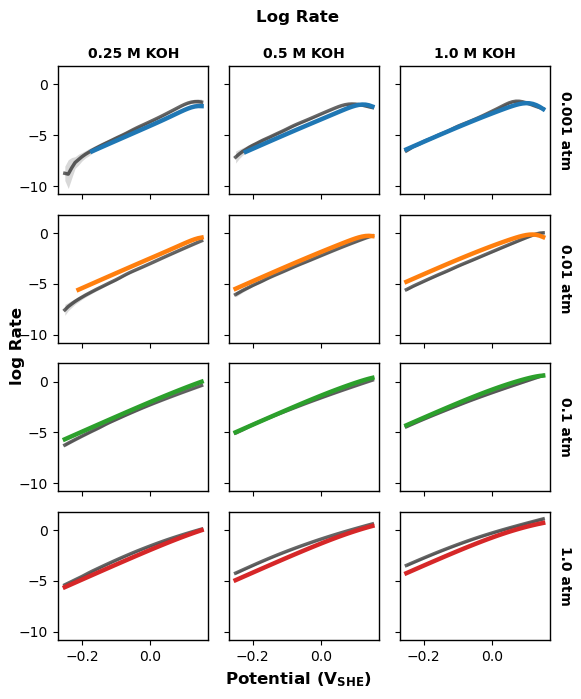

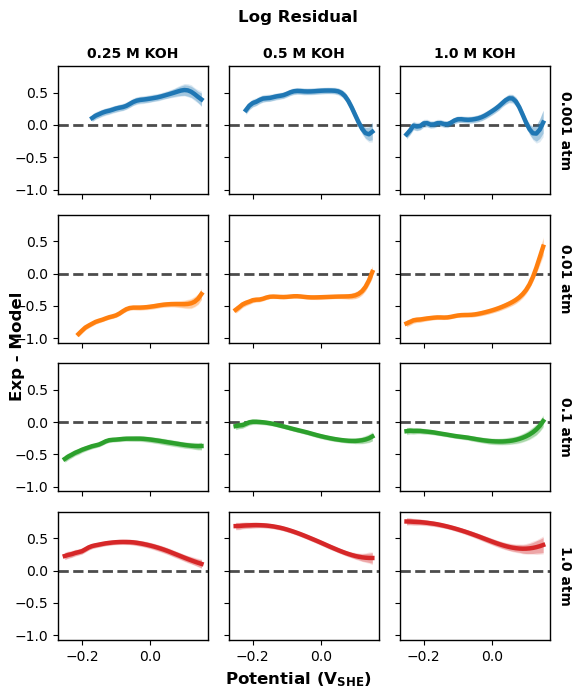

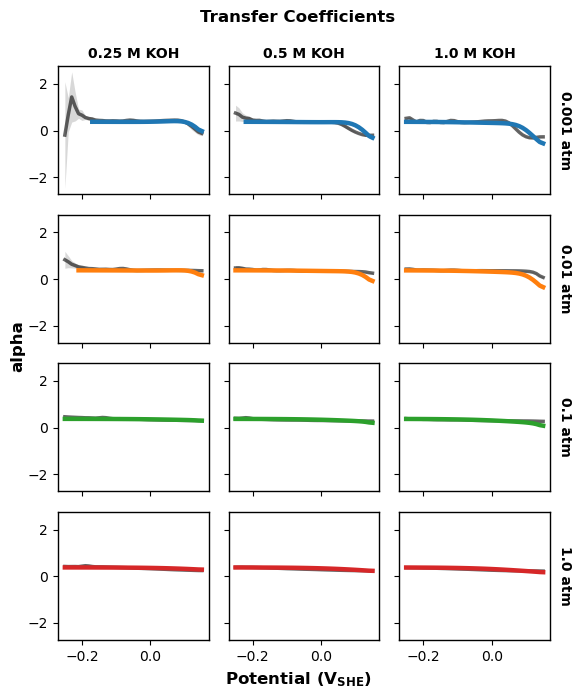

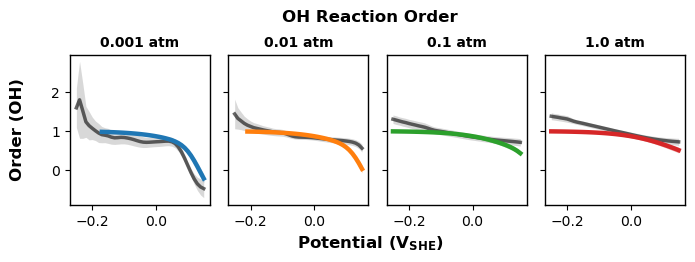

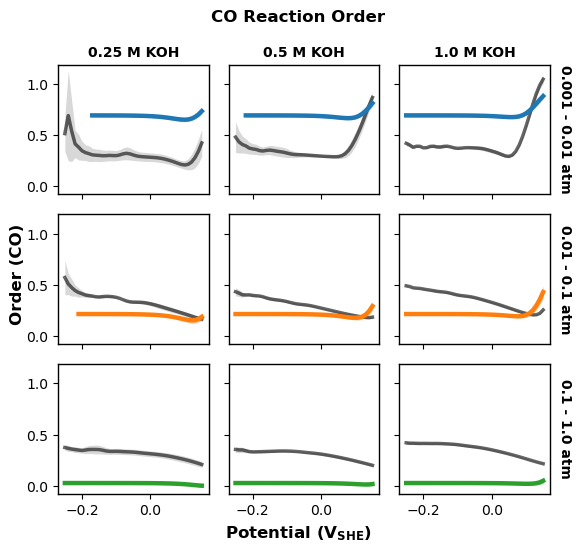

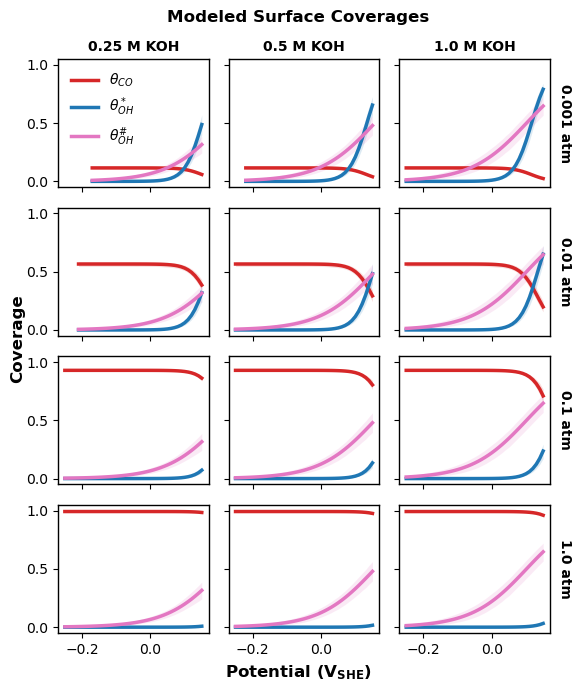

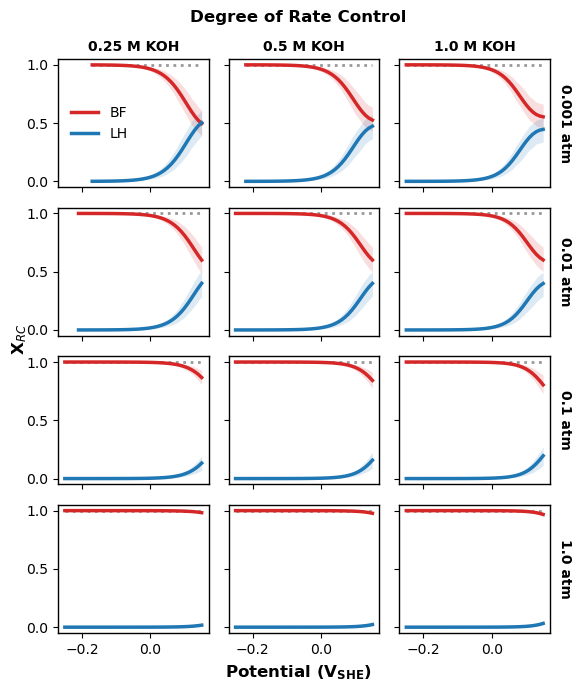

In [3]:
with pm.Model() as BF_LH:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH(q-1)# -> COOH* + # + (1-q)(e-) (RDS) (BF)
    2b. CO* + OH* -> COOH* + * (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH(q-1)# + (q)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) 
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2)
    beta_2 = pm.Uniform('beta_2', lower=0.0, upper=1.0)
    q = pm.Uniform('q', lower=0.0, upper=1.0)
    Gact2_BF_0 = pm.TruncatedNormal('Gact2_BF_0', mu=0.7, sigma=0.2, lower=0.0)
    Gact2_LH_0 = pm.TruncatedNormal('Gact2_LH_0', mu=0.7, sigma=0.2, lower=0.0)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - q * E_in
    Gact2_BF = Gact2_BF_0 - beta_2 * (1.0 - q) * E_in
    Gact2_LH = Gact2_LH_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2_BF + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    log_rate_LH = log_k2_LH + log_theta_CO + log_theta_OH_Pd + np.log(1-Ag_comp)
    log_rate = pt.logaddexp(log_rate_BF, log_rate_LH)
    rate = observables(log_rate) 

trace_BF_LH, loo_BF_LH = fit_and_evaluate(BF_LH, target_accept=0.99)

ppc_BF_LH  = plot_posteriors(trace_BF_LH , BF_LH)
plot_model_fits(trace_BF_LH, ppc_BF_LH, loo_BF_LH); plot_coverages(trace_BF_LH)
plot_drc(BF_LH, trace_BF_LH, perturb_vars=['Gact2_BF_0', 'Gact2_LH_0'], perturb_labels=['BF', 'LH'])

# Final

Progress,Draws,Divergences,Step Size,Gradients/Draw
,4000,0,0.06,63
,4000,0,0.09,127
,4000,0,0.10,31
,4000,0,0.07,127


Computed from 8000 posterior samples and 1431 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  2982.19    66.42
p_loo        7.05        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1431  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



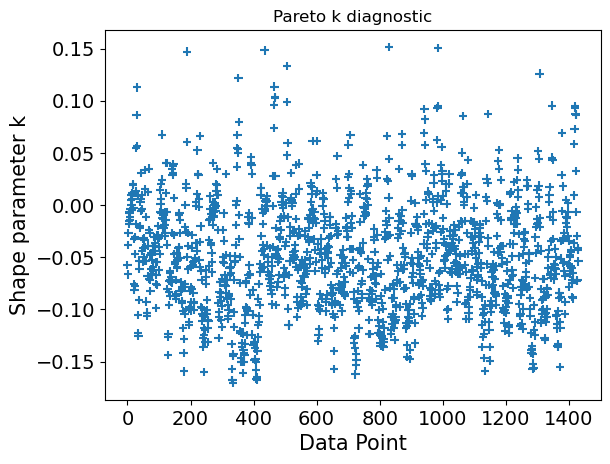

Sampling: [Gact1_0, Gact2_BF_0, Gact2_ER_0, Gact2_LH_0, beta_2_BF, beta_2_ER, deltaG1_0, deltaG4_0, deltaG5_0, q, sigma_rel]


             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG4_0   0.109  0.004   0.102    0.117      0.000    0.000    1773.0    2632.0   1.00
deltaG5_0   0.002  0.016  -0.023    0.036      0.001    0.001     430.0     341.0   1.01
deltaG1_0  -0.123  0.001  -0.125   -0.121      0.000    0.000    4518.0    5223.0   1.00
beta_2_BF   0.061  0.047   0.000    0.144      0.001    0.001    1784.0    2095.0   1.00
beta_2_ER   0.366  0.087   0.286    0.512      0.004    0.011    1356.0     420.0   1.01
q           0.402  0.058   0.302    0.521      0.002    0.001     588.0     623.0   1.00
Gact1_0     0.405  0.092   0.229    0.539      0.002    0.002    3298.0    1947.0   1.00
Gact2_BF_0  0.703  0.018   0.663    0.729      0.001    0.001     419.0     311.0   1.01
Gact2_ER_0  0.792  0.041   0.766    0.877      0.003    0.006     395.0     193.0   1.01
Gact2_LH_0  0.720  0.004   0.714    0.727      0.000    0.000    3038.0    3566.0   1.00
sigma_rel   0.411  0.

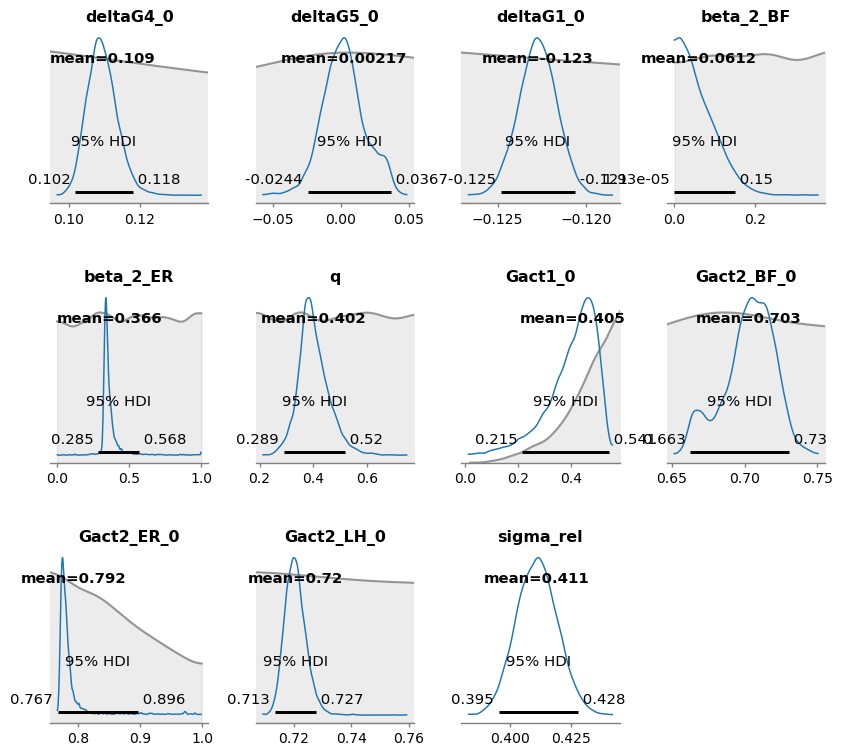

c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\plots\backends\matplotlib\pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


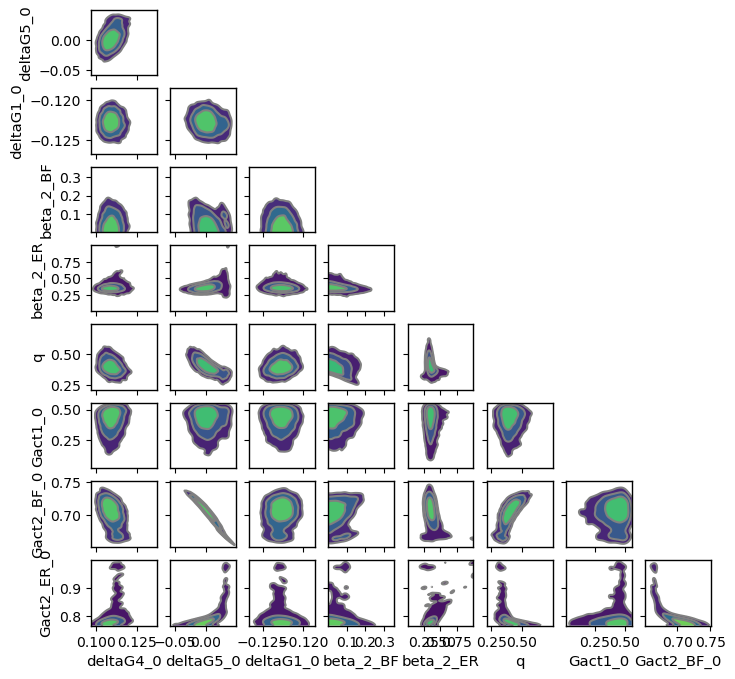

Sampling: [rate]


rate: 0.769


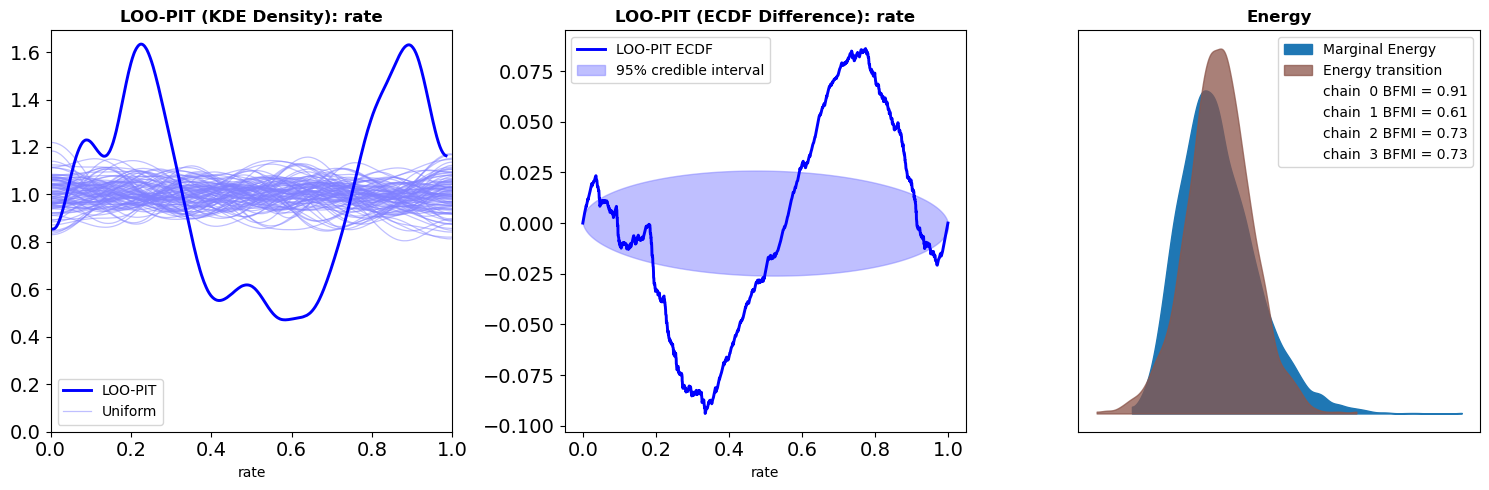

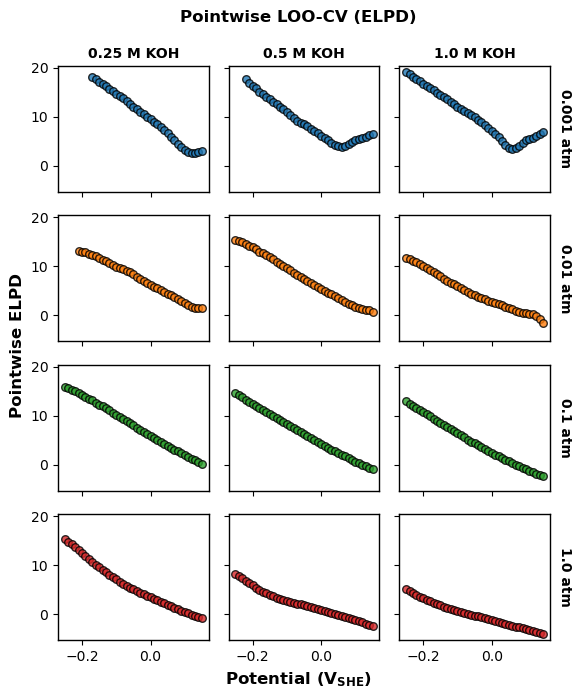

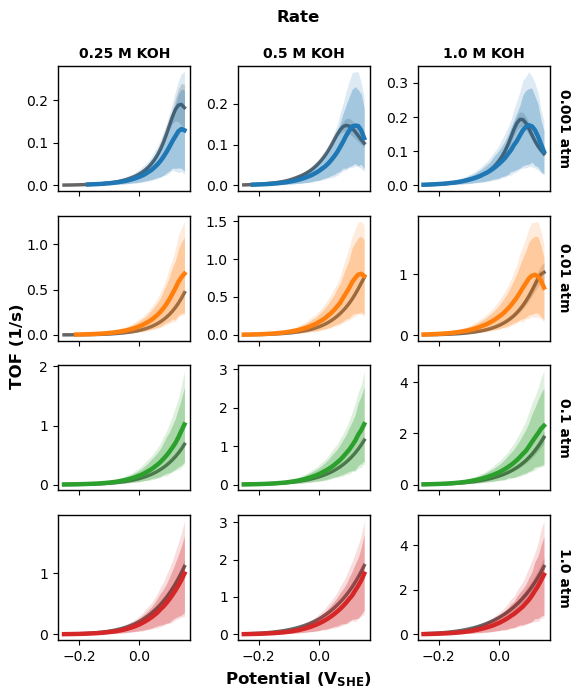

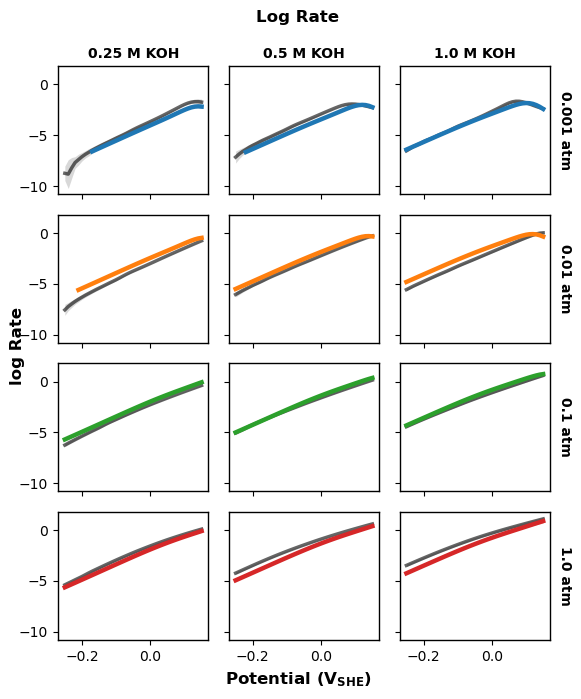

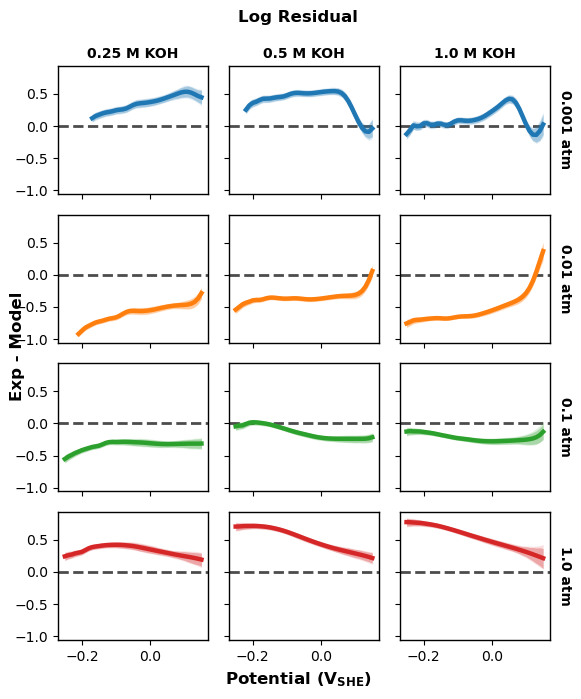

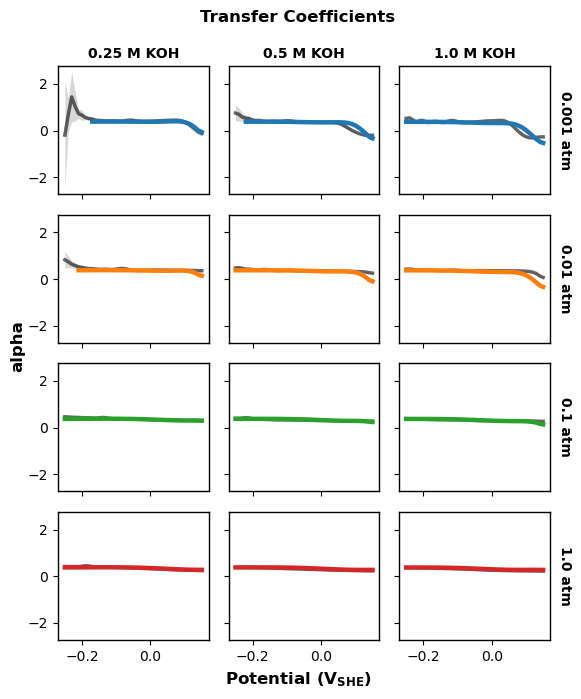

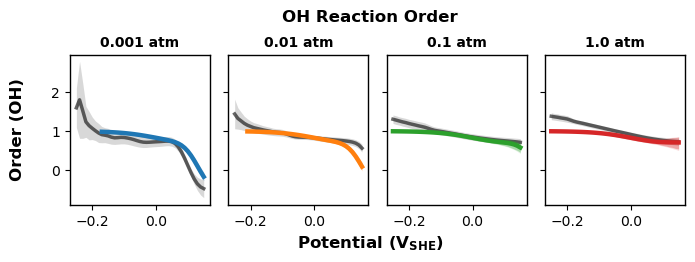

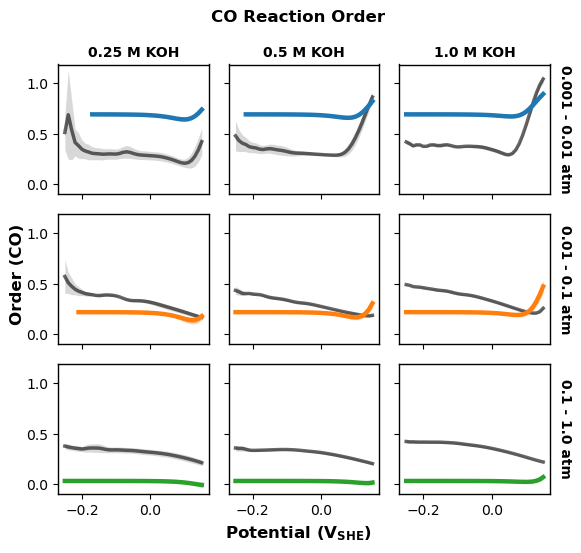

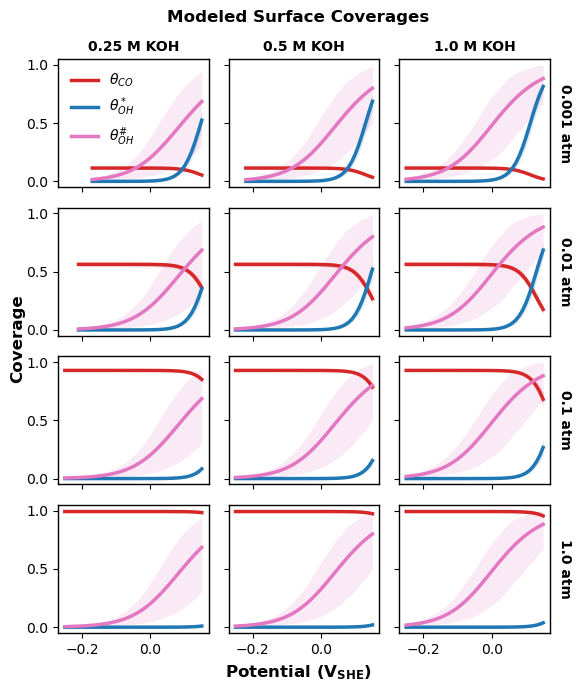

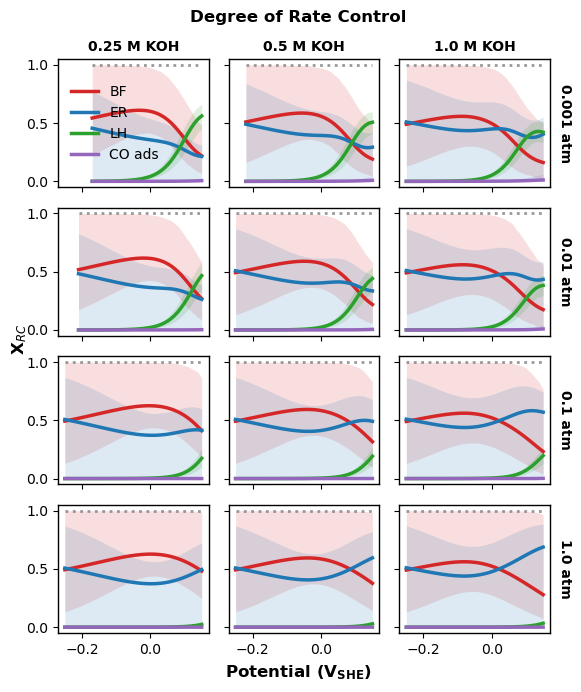

In [6]:
with pm.Model() as CO_BF_ER_LH:
    '''
    1. CO + * <-> CO* (SSA)
    2a. CO* + OH(q-1)# -> COOH* + # + (1-q)(e-) (SSA) (BF)
    2b. CO* + OH- -> COOH* + * + (e-) (SSA) (ER)
    2c. CO* + OH* -> COOH* + * (SSA) (LH)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH(q-1)# + (q)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.TruncatedNormal('deltaG1_0', mu=-0.4, sigma=0.2, upper=0.0, lower=-0.4)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2)
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) 
    beta_2_BF = pm.Uniform('beta_2_BF', lower=0.0, upper=1.0)
    beta_2_ER = pm.Uniform('beta_2_ER', lower=0.0, upper=1.0)
    q = pm.Uniform('q', lower=0.0, upper=1.0)
    Gact1_0 = pm.TruncatedNormal('Gact1_0', mu=0.7, sigma=0.2, lower=0.0, upper=1.0)
    Gact2_BF_0 = pm.TruncatedNormal('Gact2_BF_0', mu=0.7, sigma=0.2, lower=0.5, upper=1.0)
    Gact2_ER_0 = pm.TruncatedNormal('Gact2_ER_0', mu=0.7, sigma=0.2, lower=0.5, upper=1.0)
    Gact2_LH_0 = pm.TruncatedNormal('Gact2_LH_0', mu=0.7, sigma=0.2, lower=0.5, upper=1.0)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - q * E_in
    Gact1 = Gact1_0
    Gact2_BF = Gact2_BF_0 - beta_2_BF * (1.0 - q) * E_in
    Gact2_ER = Gact2_ER_0 - beta_2_ER * E_in
    Gact2_LH = Gact2_LH_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k1 = np.log(kb_J*T/h) - Gact1/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)

    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_OH_Ag)
    log_theta_Ag = -pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    log_A_Pd = pt.logsumexp(pt.stack([zeros, term_OH_Pd]), axis=0) 
    log_k1_PCO = log_k1 + np.log(P_CO_in)                    
    log_k_minus_1 = log_k1 - log_K1                                
    log_k_BF_app = log_k2_BF + log_theta_OH_Ag + np.log(Ag_comp)     
    log_k_ER_app = log_k2_ER + np.log(C_KOH_in)
    log_k_LH_app = log_k2_LH + term_OH_Pd + np.log(1.0 - Ag_comp) 

    # Quadratic solution for empty Pd site fraction
    k1_PCO = pt.exp(log_k1_PCO)
    A_Pd = pt.exp(log_A_Pd)
    log_k_cons = pt.logaddexp(pt.logaddexp(log_k_BF_app, log_k_ER_app), log_k_minus_1)
    k_cons = pt.exp(log_k_cons)
    k_LH_app = pt.exp(log_k_LH_app)
    a = k_LH_app * A_Pd
    b = k1_PCO + k_cons * A_Pd - k_LH_app
    c = -k_cons
    theta_empty_Pd_val = (2 * c) / (-b - pt.sqrt(b**2 - 4 * a * c)) # Analytical solution to quadratic SSA
    log_theta_Pd = pt.log(theta_empty_Pd_val)
    log_theta_CO = pt.log(1.0 - A_Pd * theta_empty_Pd_val)
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_k_total_app = pt.logaddexp(pt.logaddexp(log_k_BF_app, log_k_ER_app), log_k_LH_app + log_theta_Pd) 
    log_rate = log_k_total_app + log_theta_CO
    rate = observables(log_rate)

trace_CO_BF_ER_LH, loo_CO_BF_ER_LH = fit_and_evaluate(CO_BF_ER_LH, target_accept=0.95, draws=2000)

ppc_CO_BF_ER_LH = plot_posteriors(trace_CO_BF_ER_LH, CO_BF_ER_LH)
plot_model_fits(trace_CO_BF_ER_LH, ppc_CO_BF_ER_LH, loo_CO_BF_ER_LH); plot_coverages(trace_CO_BF_ER_LH)
plot_drc(CO_BF_ER_LH, trace_CO_BF_ER_LH, perturb_vars=['Gact2_BF_0', 'Gact2_ER_0', 'Gact2_LH_0', 'Gact1_0'], perturb_labels=['BF', 'ER', 'LH', 'CO ads'])

# Comparison

             rank     elpd_loo     p_loo  elpd_diff        weight         se       dse  warning scale
CO_BF_ER_LH     0  2982.194425  7.054194   0.000000  1.000000e+00  66.422520  0.000000    False   log
BF_LH           1  2978.360175  6.102783   3.834250  3.582135e-13  66.476322  1.880211    False   log
BF              2  2965.996779  5.579437  16.197646  0.000000e+00  66.724289  3.917598    False   log


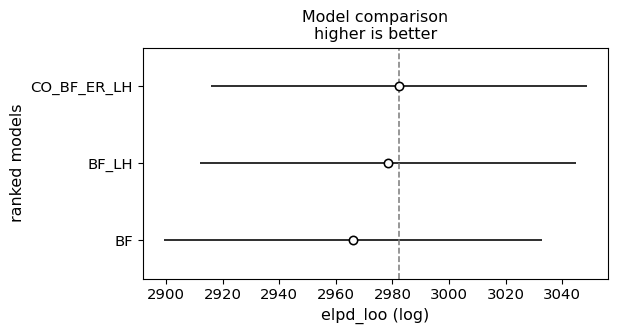

In [7]:
comparison_dict = {
    "BF": loo_BF,
    "BF_LH": loo_BF_LH,
    "CO_BF_ER_LH": loo_CO_BF_ER_LH
}

comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)
plt.show()